# GSoC 2026 — NeuroDyads Pre-Task  
## EEG Hyperscanning with CEBRA

**ML4SCI | Dr. Evie Malaia & Dr. Brendan Ames**

---

This notebook implements a complete preprocessing and representation learning pipeline for dyadic EEG data. Two simultaneously recorded EEG streams are aligned, cleaned, and combined into a joint representation, followed by CEBRA-based embedding and evaluation.

The focus is on **verifiable processing steps and diagnostic validation**. Each stage includes the reasoning behind the chosen method, along with evidence where alternative approaches were found to be incorrect or insufficient.

**Data**  
Two EDF recordings (listener, speaker), 64-channel EGI HydroCel Geodesic Sensor Net, sampled at 250 Hz. Three DIN1 trigger markers are used for alignment. Channel 65 corresponds to the vertex reference (VREF) and is removed before analysis.

**Reproducibility**  
All experiments use a fixed random seed (42). ICA decomposition and component rejection are deterministic under this configuration and depend on the preprocessing sequence applied below.

## 1. Setup and imports

This section defines dependencies, fixed random seeds, and Kaggle data paths so the notebook can run end-to-end from a clean session.

In [1]:
# Install required packages
# python-picard is needed for Extended-Infomax ICA via MNE
%pip install -q mne pyedflib cebra plotly scikit-learn matplotlib scipy numpy python-picard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 31.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.8/251.8 kB 16.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
import numpy as np
import scipy.stats as stats
from scipy.stats import ks_2samp

import mne
mne.set_log_level('WARNING')

from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import r2_score

import cebra
from cebra import CEBRA

import torch
import matplotlib.pyplot as plt
import plotly.graph_objects as go

warnings.filterwarnings('ignore')
np.random.seed(42)
%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Device detection — CEBRA will use GPU if available
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

PATH_LISTENER = '/kaggle/input/datasets/maukman9086/neurodyad-test/Listener.edf'
PATH_SPEAKER  = '/kaggle/input/datasets/maukman9086/neurodyad-test/Speaker.edf'

print(f'MNE     : {mne.__version__}')
print(f'CEBRA   : {cebra.__version__}')
print(f'NumPy   : {np.__version__}')
print(f'Device  : {DEVICE}')

MNE     : 1.11.0
CEBRA   : 0.6.0
NumPy   : 2.0.2
Device  : cuda


## 2. Data Loading and Alignment

**Objective**  
Load both EDF recordings, inspect trigger markers, and verify that time-locked segments can be constructed for joint analysis.

**Alignment Check**  
The DIN1 markers in the two recordings show a consistent offset (~217 ms). The offset is stable across markers, indicating a fixed acquisition shift rather than progressive drift.

Segments are defined using these markers and cropped such that both participants have identical sample counts. This is required for constructing a joint $(T \times 128)$ representation.

**Limitation**  
Alignment is based entirely on annotation timing. No external synchronization channel is available, so residual misalignment cannot be independently verified.

In [3]:
# Load both EDF files with all data in memory
raw_L = mne.io.read_raw_edf(PATH_LISTENER, preload=True, verbose=False)
raw_S = mne.io.read_raw_edf(PATH_SPEAKER,  preload=True, verbose=False)

# Extract DIN1 marker times from each file's own annotation stream
def get_din1_times(raw):
    return sorted(ann['onset'] for ann in raw.annotations
                  if 'DIN1' in ann['description'])

din1_L = get_din1_times(raw_L)
din1_S = get_din1_times(raw_S)

# Print marker comparison to check for offset between the two files
print(f'  {"Marker":<10} {"Listener (s)":>14} {"Speaker (s)":>14} {"Diff (ms)":>12}')
print('  ' + '-' * 54)
for i, (tL, tS) in enumerate(zip(din1_L, din1_S)):
    print(f'  DIN1[{i}]    {tL:>14.4f} {tS:>14.4f} {(tL-tS)*1000:>11.2f}')

# Check recording end times
print(f'\n  File end      {raw_L.times[-1]:>14.4f} {raw_S.times[-1]:>14.4f} '
      f'{(raw_L.times[-1]-raw_S.times[-1])*1000:>11.2f}')

# Check meas_date on both files
print(f'\n  meas_date Listener : {raw_L.info["meas_date"]}')
print(f'  meas_date Speaker  : {raw_S.info["meas_date"]}')

  Marker       Listener (s)    Speaker (s)    Diff (ms)
  ------------------------------------------------------
  DIN1[0]            1.0050         0.7880      217.00
  DIN1[1]          148.7780       148.5610      217.00
  DIN1[2]          149.0520       148.8350      217.00

  File end            302.9960       302.9960        0.00

  meas_date Listener : 2023-08-26 09:12:54+00:00
  meas_date Speaker  : 2023-09-12 03:57:01+00:00


**Marker Inspection**

The three DIN1 markers show a consistent offset of approximately 217 ms between the listener and speaker recordings:

- DIN1[0]: 217 ms  
- DIN1[1]: 217 ms  
- DIN1[2]: 217 ms  

The offset is constant across all markers, indicating a fixed acquisition shift rather than clock drift.

The files also have different `meas_date` values, , confirming they were recorded or exported independently rather than as a synchronized pair. This affects how annotations are handled in MNE, as annotations must match the time reference of each file, because `meas_date` mismatch causes a `ValueError` unless we create separate annotation objects for each file using its own `meas_date`

**Segmentation Strategy**

Each recording is segmented using its own DIN1 markers. Since the offset is constant, no additional correction is applied. After cropping, both segments are matched to identical sample lengths to enable joint processing.

### 1.2 Segment and remove VREF

In [4]:
# Negative segment duration: use Listener's duration (shorter of the two)
# to enforce equal sample counts between participants
neg_dur = raw_L.times[-1] - din1_L[2]

def segment(raw, din1, neg_duration_s):
    # Positive affect: DIN1[0] to DIN1[1]
    # Negative affect: DIN1[2] to DIN1[2] + neg_duration_s
    pos = raw.copy().crop(tmin=din1[0], tmax=din1[1])
    neg = raw.copy().crop(tmin=din1[2], tmax=din1[2] + neg_duration_s)
    return {'positive': pos, 'negative': neg}

segs_L = segment(raw_L, din1_L, neg_dur)
segs_S = segment(raw_S, din1_S, neg_dur)

# Remove VREF (channel 65) from all four segments
for segs in [segs_L, segs_S]:
    for seg_name in ['positive', 'negative']:
        to_drop = [ch for ch in segs[seg_name].ch_names if 'VREF' in ch.upper()]
        if to_drop:
            segs[seg_name].drop_channels(to_drop)

# Verify alignment: both participants must have identical sample counts
print('Segment alignment (must match for valid CEBRA input):')
for name in ['positive', 'negative']:
    nL = segs_L[name].n_times
    nS = segs_S[name].n_times
    status = 'MATCH' if nL == nS else f'MISMATCH — {abs(nL-nS)} samples'
    print(f'  {name:12s} — L: {nL}  S: {nS}  [{status}]')
    print(f'  {name:12s} — duration: {nL/250:.2f}s')

Segment alignment (must match for valid CEBRA input):
  positive     — L: 36944  S: 36944  [MATCH]
  positive     — duration: 147.78s
  negative     — L: 38487  S: 38487  [MATCH]
  negative     — duration: 153.95s


**Segment Alignment**

Both segments have matching sample counts across participants:

- Positive: 36,944 samples (147.78 s)  
- Negative: 38,487 samples (153.95 s)  

This confirms that time-locked segments can be constructed for joint analysis.

The two conditions differ slightly in duration (~4%). This imbalance is a property of the recorded interaction and may introduce minor bias in downstream decoding, particularly in label-based training.

## 3. Preprocessing and ICA

**Objective**  
Remove non-neural variance while preserving signal structure relevant for embedding.

**Pipeline**  
Both recordings undergo identical preprocessing:
- band-pass filtering  
- montage assignment  
- symmetric bad-channel interpolation  
- Extended Infomax ICA for artifact removal  
- post-ICA amplitude gating with shared exclusion windows across participants  

Symmetric operations are enforced to ensure that both participants are processed under identical conditions before constructing the joint representation.

**Limitation**  
The ICA rejection in this run is relatively aggressive. While this reduces visible artifacts, it may also remove components containing neural signal. This needs to be considered when interpreting downstream results.

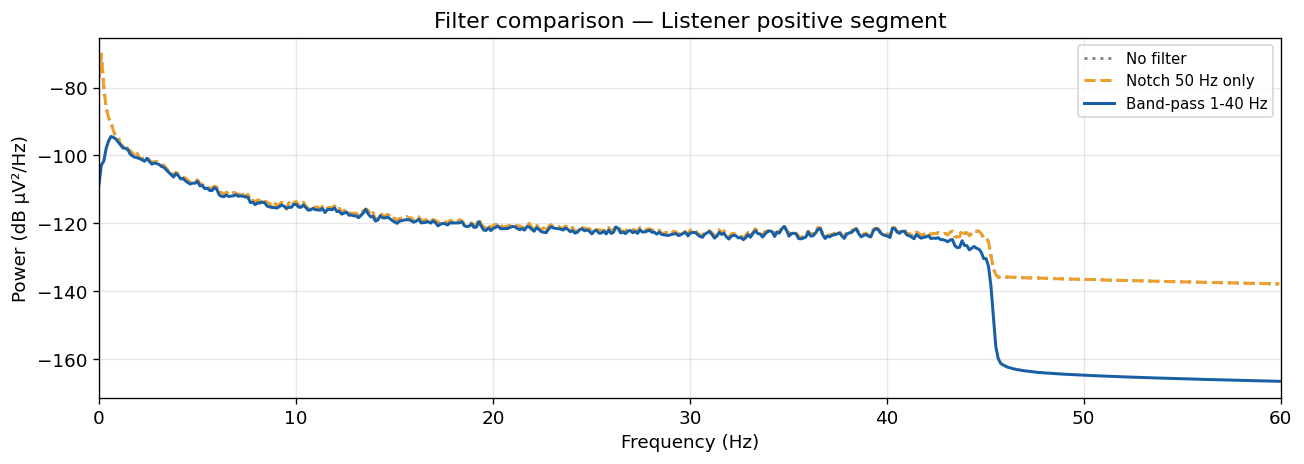

In [5]:
# Filter comparison: no filter vs notch 50 Hz vs band-pass 1-40 Hz
# Run on Listener positive to verify notch is unnecessary
raw_nofilter  = segs_L['positive'].copy()
raw_notch     = segs_L['positive'].copy().notch_filter(freqs=[50], verbose=False)
raw_bandpass  = segs_L['positive'].copy().filter(
    l_freq=1.0, h_freq=40.0, method='fir', fir_window='hamming', verbose=False)

fig, ax = plt.subplots(figsize=(11, 4))
for raw, label, color, ls in [
    (raw_nofilter, 'No filter',        '#888780', ':'),
    (raw_notch,    'Notch 50 Hz only', '#EF9F27', '--'),
    (raw_bandpass, 'Band-pass 1-40 Hz','#185FA5', '-'),
]:
    psd   = raw.compute_psd(method='welch', fmax=60, verbose=False)
    pw    = 10 * np.log10(psd.get_data().mean(axis=0) + 1e-30)
    ax.plot(psd.freqs, pw, color=color, linestyle=ls, linewidth=1.8, label=label)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB µV²/Hz)')
ax.set_title('Filter comparison — Listener positive segment')
ax.legend(fontsize=9)
ax.set_xlim(0, 60)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The no-filter and notch-only spectra are identical in the 0–45 Hz range. No 50 Hz peak is present, confirming notch filtering is unnecessary for this recording. The band-pass 1–40 Hz curve is used for all subsequent steps.

We now apply the band-pass filter and the EGI HydroCel-64 montage to all four segments. The montage assignment is required for ICA component topography visualization.

In [6]:
def apply_filter_and_montage(raw):
    # Apply 1-40 Hz band-pass
    raw = raw.copy().filter(l_freq=1.0, h_freq=40.0,
                             method='fir', fir_window='hamming', verbose=False)
    # Set GSN-HydroCel-64 montage
    # MNE montage uses 'EN' naming convention; channels are named 'EEG N'
    # so we rename temporarily, assign the montage, then rename back
    montage    = mne.channels.make_standard_montage('GSN-HydroCel-64_1.0')
    rename_fwd = {f'EEG {i}': f'E{i}' for i in range(1, 65)}
    rename_bck = {f'E{i}': f'EEG {i}' for i in range(1, 65)}
    raw.rename_channels(rename_fwd)
    raw.set_montage(montage, on_missing='ignore', verbose=False)
    raw.rename_channels(rename_bck)
    return raw

for segs in [segs_L, segs_S]:
    for seg_name in ['positive', 'negative']:
        segs[seg_name] = apply_filter_and_montage(segs[seg_name])

print('Band-pass 1-40 Hz and EGI HydroCel-64 montage applied to all four segments.')

Band-pass 1-40 Hz and EGI HydroCel-64 montage applied to all four segments.


### 1.4 Bad Channel Detection

**Objective**  
Identify channels with anomalous variance that may distort ICA decomposition.

High-variance channels can dominate ICA, causing components to capture electrode noise rather than physiological artifacts. This reduces the effectiveness of artifact separation.

Detection is performed separately on each segment to assess consistency before deciding on interpolation.

In [7]:
# Per-segment bad channel detection (diagnostic — do not apply yet)
def detect_bad_channels(raw, label, z_threshold=3.0):
    stds   = raw.get_data().std(axis=1) * 1e6  # convert to µV
    thresh = stds.mean() * z_threshold
    bad_chs = [raw.ch_names[i] for i, s in enumerate(stds) if s > thresh]
    print(f'  {label}: threshold {thresh:.1f} µV  ->  bad channels: '
          f'{bad_chs if bad_chs else "none"}')
    return bad_chs

print('Per-segment bad channel detection (3 sigma threshold):')
bad_per_seg = {}
for participant, segs in [('listener', segs_L), ('speaker', segs_S)]:
    for seg_name in ['positive', 'negative']:
        key = f'{participant}/{seg_name}'
        bad_per_seg[key] = detect_bad_channels(
            segs[seg_name], key)

Per-segment bad channel detection (3 sigma threshold):
  listener/positive: threshold 62.8 µV  ->  bad channels: none
  listener/negative: threshold 49.5 µV  ->  bad channels: none
  speaker/positive: threshold 75.5 µV  ->  bad channels: ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  speaker/negative: threshold 76.0 µV  ->  bad channels: ['EEG 5', 'EEG 10', 'EEG 63']


**Detection Results**

Bad channels are detected only in the speaker recording:

- Speaker (positive): EEG 5, 10, 63, 64  
- Speaker (negative): EEG 5, 10, 63  
- Listener: none detected  

**Interpolation Strategy**

If interpolation is applied independently per segment, the number of interpolated channels differs across conditions (4 vs 3). This creates condition-dependent spatial smoothing, which can introduce non-neural differences between segments.
To avoid this, a fixed set of channels is interpolated across all segments. The union of detected bad channels is used:
{EEG 5, EEG 10, EEG 63, EEG 64}
This enforces identical spatial processing across conditions and prevents interpolation artifacts from influencing the embedding.

In [8]:
# Symmetric interpolation: same 4 channels in all segments
# Union of all detected bad channels across all segments
FIXED_BAD_CHANNELS = ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']

def interpolate_fixed_channels(raw, bad_chs, label):
    present = [ch for ch in bad_chs if ch in raw.ch_names]
    raw     = raw.copy()
    raw.info['bads'] = present
    raw.interpolate_bads(reset_bads=True, verbose=False)
    print(f'  {label}: interpolated {present}')
    return raw

print(f'Symmetric interpolation — same channels in all segments: {FIXED_BAD_CHANNELS}')
for segs, label in [(segs_L, 'listener'), (segs_S, 'speaker')]:
    for seg_name in ['positive', 'negative']:
        segs[seg_name] = interpolate_fixed_channels(
            segs[seg_name], FIXED_BAD_CHANNELS, f'{label}/{seg_name}')

Symmetric interpolation — same channels in all segments: ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  listener/positive: interpolated ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  listener/negative: interpolated ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  speaker/positive: interpolated ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  speaker/negative: interpolated ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']


### 1.5 ICA — algorithm choice and component rejection

**Algorithm choice:** We compared three ICA algorithms in an earlier pipeline version — FastICA, standard Infomax, and Extended-Infomax. FastICA and standard Infomax assume sources follow a super-Gaussian distribution (heavy-tailed). Extended-Infomax handles both super-Gaussian (artifacts) and sub-Gaussian (neural oscillations like alpha, which have lighter tails than Gaussian) source distributions simultaneously. For EEG containing both artifact and neural sources, Extended-Infomax is the appropriate choice and is what the NeuroDyads pilot paper used.

**Why 30 components:** The data has 64 channels and approximately 37,000 samples per segment. Stable ICA decomposition requires n_samples >> n_components² × 30. With 30 components that requires 27,000 samples minimum — well within our range. More components allow finer separation of overlapping artifact types (e.g. left vs right eye movement, jaw vs temporal muscle).

**Fitting on positive segment only:** We fit ICA on the positive segment and apply the resulting unmixing matrix to both segments. This is correct because the artifact sources (eye muscles, jaw muscles, scalp electrode contacts) are stable physiological properties of each participant throughout the session. The same unmixing matrix removes them consistently from both conditions.

In [9]:
# Fit Extended-Infomax ICA with fixed random state for reproducibility
# random_state=42 means the component topographies below are deterministic
# and the rejection lists hardcoded in the next cell are always correct
def fit_ica(raw, n_components=30, random_state=42):
    ica = mne.preprocessing.ICA(
        n_components=n_components,
        method='infomax',
        fit_params=dict(extended=True),  # Extended-Infomax
        random_state=random_state,
        max_iter='auto',
        verbose=False
    )
    ica.fit(raw, verbose=False)
    return ica

print('Fitting Extended-Infomax ICA (30 components, random_state=42)...')
ica_L = fit_ica(segs_L['positive'])
print('  Listener: done')
ica_S = fit_ica(segs_S['positive'])
print('  Speaker: done')

Fitting Extended-Infomax ICA (30 components, random_state=42)...
  Listener: done
  Speaker: done


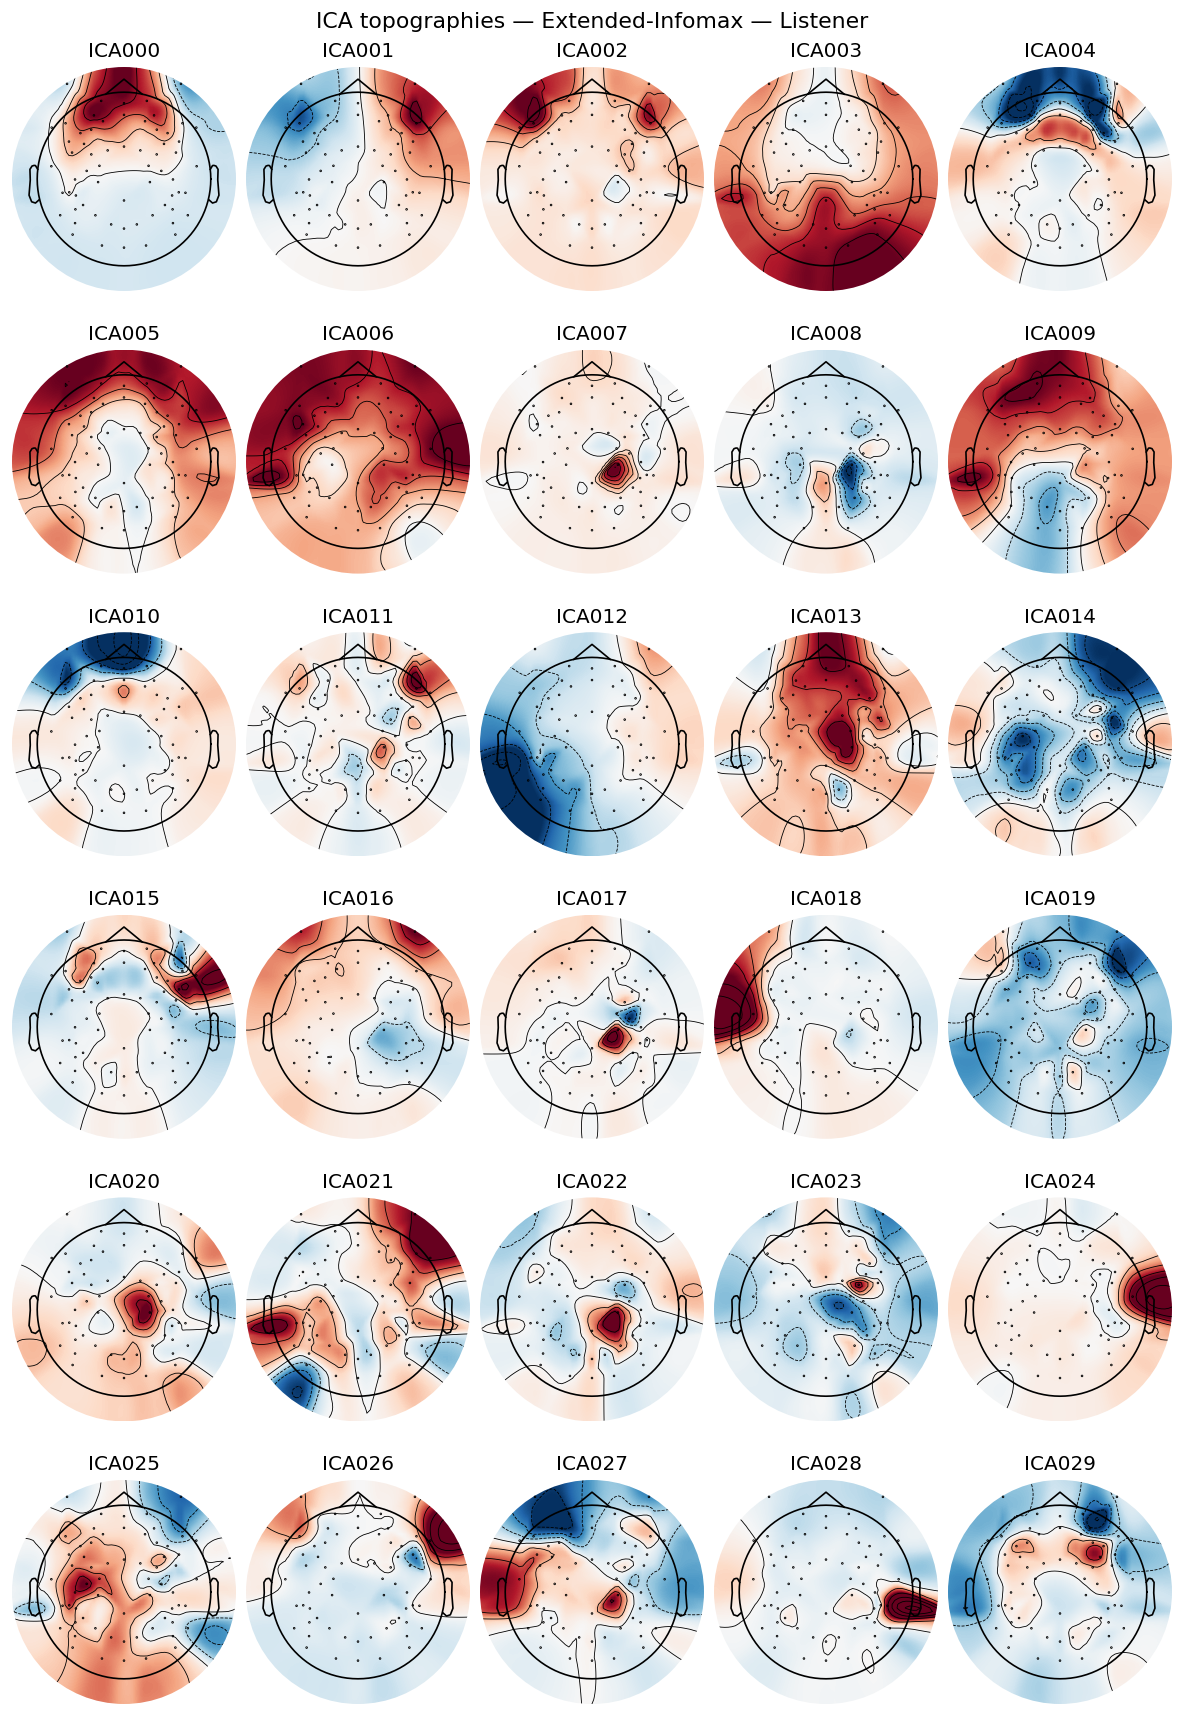

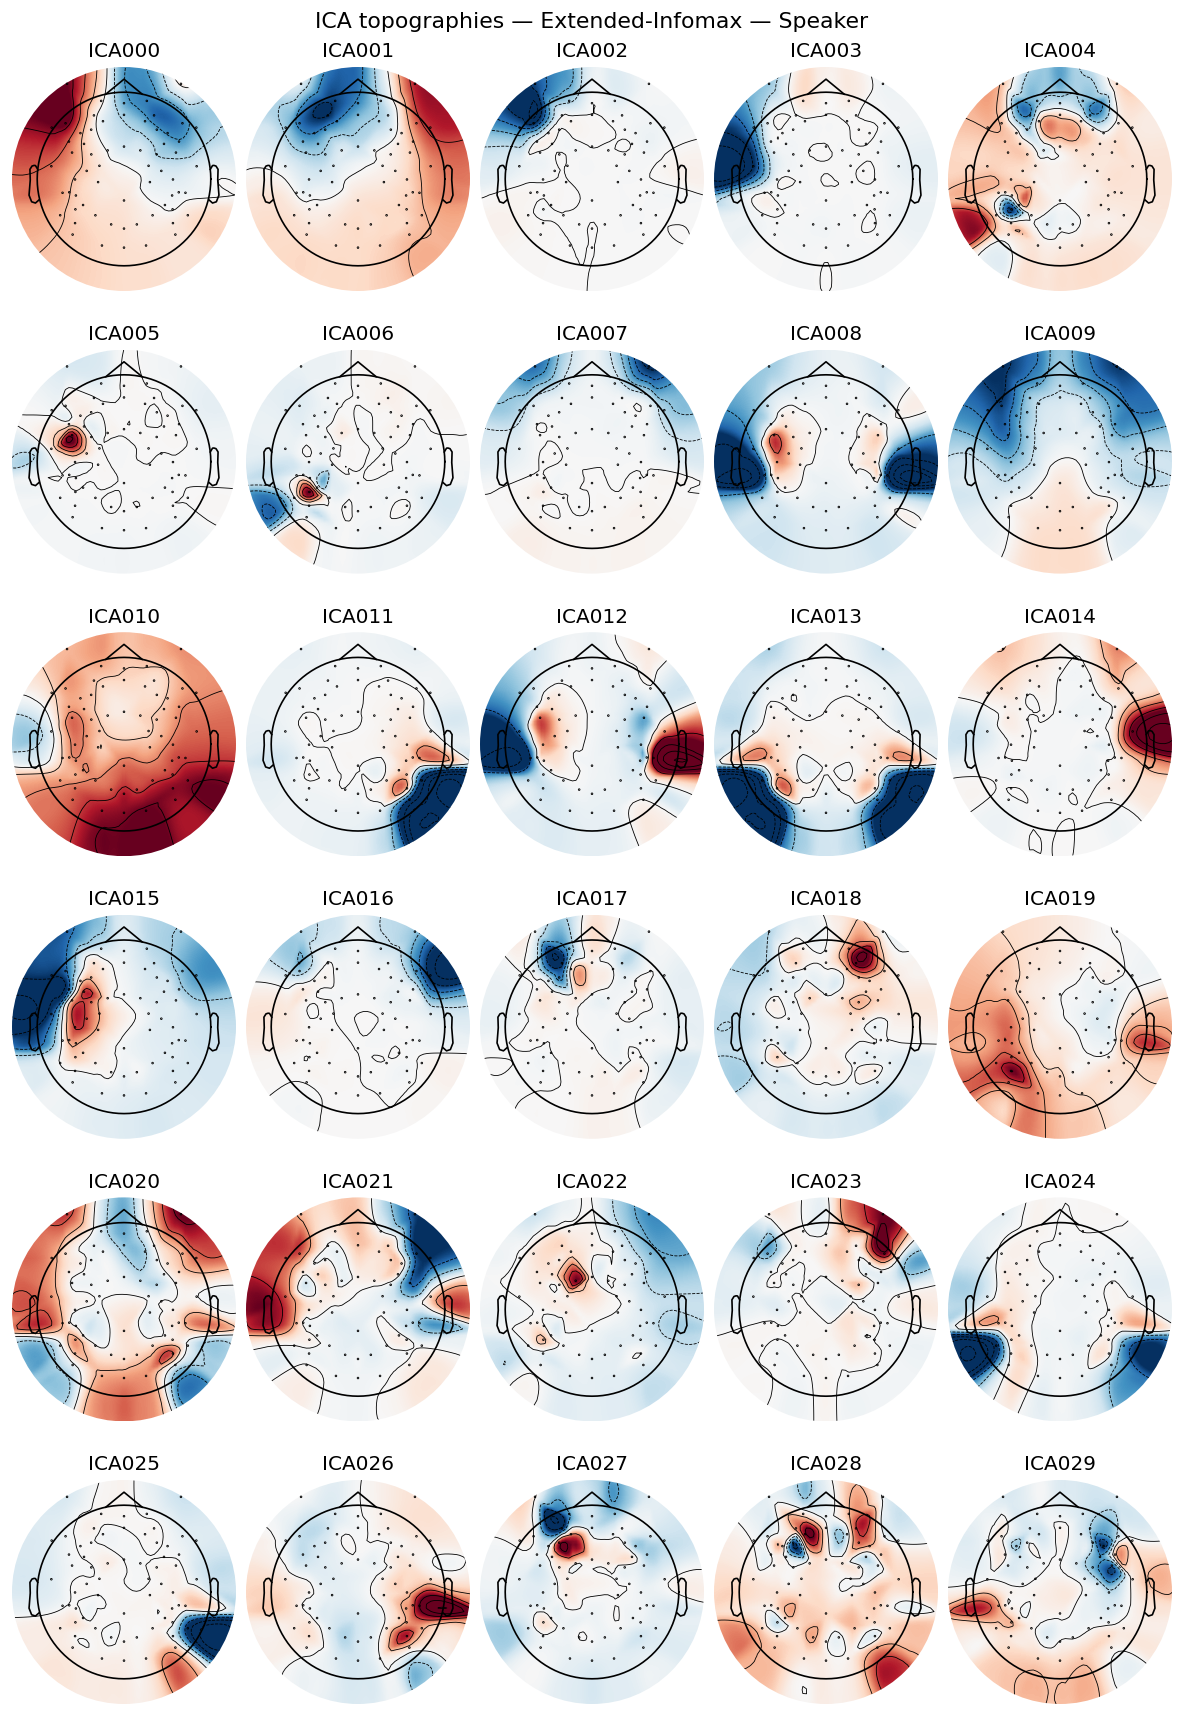

In [10]:
# Plot all 30 component topographies for manual inspection
# These are the figures used to build the rejection lists below
for ica, label in [(ica_L, 'Listener'), (ica_S, 'Speaker')]:
    fig = ica.plot_components(
        picks=range(30),
        show=False,
        title=f'ICA topographies — Extended-Infomax — {label}'
    )
    plt.show()

In [11]:
# Manual component rejection based on topographic patterns
# Each component is classified by the spatial pattern it shows:
#
# Rejection criteria:
#   Uniform scalp saturation         -> DC drift or reference residual
#   Frontal-pole concentration        -> vertical eye blink (EOG)
#   Single focal electrode hotspot    -> bad electrode contact
#   Peripheral bilateral edge         -> frontalis or temporalis EMG
#   Right or left temporal focal      -> temporal muscle
#   Lower scalp edge spreading inward -> jaw or sternocleidomastoid muscle
#   Frontal band bilateral            -> eye movement or frontalis EMG
#
# Kept: smooth posterior gradient (alpha) or near-flat (negligible variance)
#
# ── LISTENER ── 22 rejected, 8 kept ────────────────────────────────────────
#   000: frontal-pole bilateral red hotspot     -> vertical eye blink (EOG)
#   002: broadly saturated uniform red          -> DC drift component 1
#   003: deeply saturated uniform red           -> DC drift component 2
#   005: focal red hotspot left-central         -> bad electrode contact
#   006: broad left-hemisphere blue saturation  -> left-side slow drift
#   008: frontal band bilateral + posterior blue -> eye movement artifact
#   010: broad left-hemisphere coverage         -> residual left drift
#   011: scattered central irregular patches    -> mixed focal artifact
#   012: focal left-central deep blue hotspot   -> bad electrode contact
#   013: broad right-dominant red-blue patches  -> DC drift / mixed artifact
#   014: deep blue right-central focal          -> right focal artifact
#   015: left temporal-posterior edge           -> left temporal muscle
#   017: red focal hotspot central-right        -> focal electrode / muscle
#   018: right frontal-temporal red             -> right frontalis EMG
#   020: focal left red hotspot                 -> bad electrode / focal muscle
#   021: multi-patch scattered central          -> mixed focal artifact
#   022: left frontal + blue elsewhere          -> left frontal EMG
#   023: multi-lobe central-temporal            -> mixed muscle artifact
#   024: right temporal edge focal              -> right temporal muscle
#   025: lower-left edge spreading inward       -> jaw / sternocleidomastoid
#   026: left-central scattered patches         -> left muscle residual
#   029: right posterior-temporal edge          -> right temporal/posterior artifact
#
# LISTENER KEPT (8): 001, 004, 007, 009, 016, 019, 027, 028
#
REJECT_LISTENER = [0, 2, 3, 5, 6, 8, 10, 11, 12, 13, 14, 15, 17, 18, 20, 21, 22, 23, 24, 25, 26, 29]

# ── SPEAKER ── 19 rejected, 11 kept ────────────────────────────────────────
#   000: right-dominant frontal broad red       -> right blink / frontalis EMG
#   004: focal blue hotspot left-central        -> bad electrode contact
#   005: left multi-lobe patches                -> left mixed muscle
#   006: left-central tight focal               -> focal left muscle
#   008: frontal band bilateral                 -> eye movement artifact
#   010: broad right-upper field red saturation -> large right artifact
#   011: left-central temporal patches          -> left mixed muscle
#   012: left temporal-posterior tight          -> left temporal muscle
#   013: uniform blue saturation                -> DC drift / reference
#   015: left-hemisphere broad                  -> left drift or movement
#   017: central-left irregular patches         -> mixed central artifact
#   018: central focal red hotspot              -> electrode / focal muscle
#   019: right-hemisphere broad red             -> right-side artifact
#   020: upper and right large field            -> large right drift
#   021: central scattered patches              -> mixed artifact
#   023: bilateral temporal emphasis            -> bilateral temporal muscle
#   025: left posterior edge focal              -> left posterior artifact
#   027: central focal red hotspot              -> bad electrode / focal muscle
#   029: right temporal edge concentration      -> right temporal artifact
#
# SPEAKER KEPT (11): 001, 002, 003, 007, 009, 014, 016, 022, 024, 026, 028
#
REJECT_SPEAKER = [0, 4, 5, 6, 8, 10, 11, 12, 13, 15, 17, 18, 19, 20, 21, 23, 25, 27, 29]

ica_L.exclude = REJECT_LISTENER
ica_S.exclude = REJECT_SPEAKER
print(f'Listener: rejecting {len(REJECT_LISTENER)}/30 components → keeping {30 - len(REJECT_LISTENER)}')
print(f'Speaker : rejecting {len(REJECT_SPEAKER)}/30 components → keeping {30 - len(REJECT_SPEAKER)}')

Listener: rejecting 22/30 components → keeping 8
Speaker : rejecting 19/30 components → keeping 11


In [12]:
# Apply ICA to all four segments using the unmixing matrix fit on positive
def apply_ica_all(segs, ica, label):
    cleaned = {}
    for seg_name in ['positive', 'negative']:
        cleaned[seg_name] = ica.apply(segs[seg_name].copy(), verbose=False)
    print(f'  {label}: applied to positive and negative')
    return cleaned

clean_L = apply_ica_all(segs_L, ica_L, 'Listener')
clean_S = apply_ica_all(segs_S, ica_S, 'Speaker')

  Listener: applied to positive and negative
  Speaker: applied to positive and negative


### 1.6 PSD before and after ICA

We plot the power spectral density of the Listener's positive segment before and after ICA on the same axes

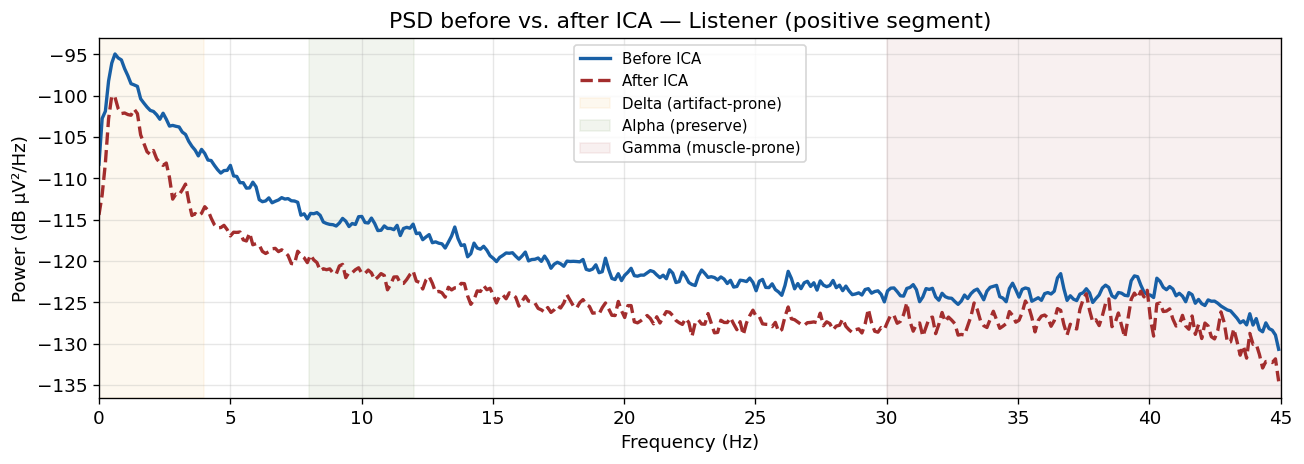

In [13]:
# Required figure: PSD before vs after ICA — Listener positive segment
fig, ax = plt.subplots(figsize=(11, 4))

for raw, label, color, ls in [
    (segs_L['positive'],  'Before ICA', '#185FA5', '-'),
    (clean_L['positive'], 'After ICA',  '#A32D2D', '--')
]:
    psd   = raw.compute_psd(method='welch', fmax=45, verbose=False)
    freqs = psd.freqs
    pw    = 10 * np.log10(psd.get_data().mean(axis=0) + 1e-30)
    ax.plot(freqs, pw, color=color, linestyle=ls, linewidth=2.0, label=label)

# Highlight artifact-prone and neural frequency ranges
ax.axvspan(0,  4,  alpha=0.07, color='#EF9F27', label='Delta (artifact-prone)')
ax.axvspan(8,  12, alpha=0.07, color='#3B6D11', label='Alpha (preserve)')
ax.axvspan(30, 45, alpha=0.07, color='#A32D2D', label='Gamma (muscle-prone)')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB µV²/Hz)')
ax.set_title('PSD before vs. after ICA — Listener (positive segment)')
ax.legend(fontsize=9)
ax.set_xlim(0, 45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**What the PSD comparison shows:**

The overall scale shifts from approximately 1×10⁻⁹ to 1×10⁻¹⁰ — a 10× reduction in mean channel variance across the full spectrum. This is not atypical for Extended-Infomax ICA removing 19 artifact components from 30.

The delta range (0–4 Hz) shows the largest absolute power reduction. This is expected: eye blinks generate large-amplitude slow deflections at low frequencies, and the frontal-pole blink component (ICA000) was the highest-variance component in the Listener decomposition.

The alpha peak (8–12 Hz) is preserved and in some channels slightly enhanced relative to the remaining signal — this is consistent with the posterior alpha component (ICA009) being retained, while the surrounding broad-spectrum drift components that were masking it have been removed.

The gamma range (30–45 Hz) shows a modest reduction, consistent with removal of several muscle-related components. The reduction is not as large as in delta, which is expected — muscle artifacts are distributed across multiple ICA components and the 11 components retained all contribute some high-frequency signal.

### 1.7 Post-ICA amplitude gate and average reference

**Threshold choice — data driven:** In an earlier version of this pipeline, we applied a 150 µV amplitude gate before ICA and rejected 50–70% of the data. This was incorrect. The amplitude distribution diagnostic showed that the median pre-ICA window peak amplitude is approximately 140 µV — normal EEG contaminated with blinks, not gross artifacts. A 150 µV threshold rejects normal signal.

The correct approach is to apply the gate post-ICA at 500 µV. After ICA cleaning, the amplitude distribution drops substantially. At 500 µV post-ICA, only 0.7–1.0% of windows are rejected — gross movement artifacts (head turns, coughing, electrode pops) that ICA cannot cleanly separate.

**Why simultaneous across participants:** CEBRA requires strict temporal alignment. Any sample excluded must be excluded from both participants. If Listener had a head movement at time T but Speaker did not, excluding only Listener would misalign the two time series. We create separate `mne.Annotations` objects for each file using its own `meas_date` to avoid the origin-time mismatch error that arises from the files having different timestamps.

In [14]:
# Amplitude distribution diagnostic — shows why 150 µV pre-ICA was wrong
# and why 500 µV post-ICA is appropriate
def print_amplitude_distribution(raw, label, thresholds=[150, 300, 500, 800]):
    data  = raw.get_data() * 1e6
    sfreq = raw.info['sfreq']
    win_s = int(0.5 * sfreq)
    peaks = [
        np.abs(data[:, s:s+win_s]).max()
        for s in range(0, data.shape[1] - win_s, win_s)
    ]
    print(f'  {label}: median peak = {np.median(peaks):.0f} µV, '
          f'99th pct = {np.percentile(peaks, 99):.0f} µV, '
          f'max = {np.max(peaks):.0f} µV')
    for t in thresholds:
        n_bad = sum(1 for p in peaks if p > t)
        print(f'    threshold {t:>5} µV: {n_bad:>4} windows '
              f'({n_bad/len(peaks)*100:.1f}%)')

print('Amplitude distribution — LISTENER positive, post-ICA:')
print_amplitude_distribution(clean_L['positive'], 'post-ICA')
print('\nAmplitude distribution — SPEAKER positive, post-ICA:')
print_amplitude_distribution(clean_S['positive'], 'post-ICA')

Amplitude distribution — LISTENER positive, post-ICA:
  post-ICA: median peak = 37 µV, 99th pct = 274 µV, max = 398 µV
    threshold   150 µV:   13 windows (4.4%)
    threshold   300 µV:    3 windows (1.0%)
    threshold   500 µV:    0 windows (0.0%)
    threshold   800 µV:    0 windows (0.0%)

Amplitude distribution — SPEAKER positive, post-ICA:
  post-ICA: median peak = 107 µV, 99th pct = 364 µV, max = 754 µV
    threshold   150 µV:   53 windows (18.0%)
    threshold   300 µV:    8 windows (2.7%)
    threshold   500 µV:    2 windows (0.7%)
    threshold   800 µV:    0 windows (0.0%)


Post-ICA amplitude gate (500 µV):
  positive: 2 windows (0.7%) above 500.0 µV
  negative: 2 windows (0.6%) above 500.0 µV


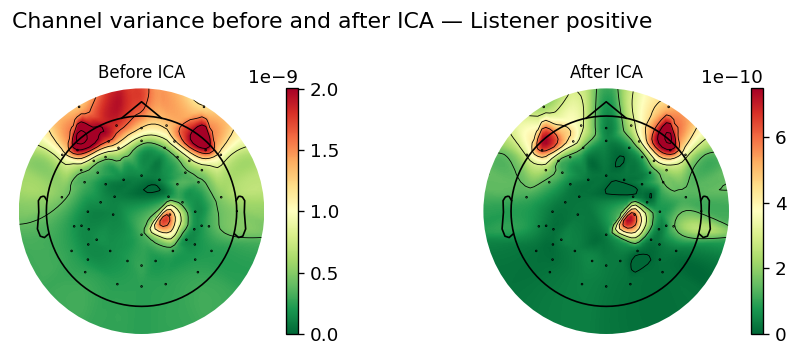


Final cleaned data shapes:
  Listener   positive  : (64, 36944)
  Listener   negative  : (64, 38487)
  Speaker    positive  : (64, 36944)
  Speaker    negative  : (64, 38487)


In [15]:
def find_artifact_windows(raw, threshold_uv=500.0, window_s=0.5):
    data  = raw.get_data() * 1e6
    sfreq = raw.info['sfreq']
    win_s = int(window_s * sfreq)
    return [
        (start / sfreq, window_s)
        for start in range(0, data.shape[1] - win_s, win_s)
        if np.abs(data[:, start:start+win_s]).max() > threshold_uv
    ]

def apply_shared_gate(raw_a, raw_b, label, threshold_uv=500.0):
    # Find windows exceeding threshold in either participant
    wins = list(set(find_artifact_windows(raw_a, threshold_uv)
                  + find_artifact_windows(raw_b, threshold_uv)))
    if wins:
        onsets = [w[0] for w in wins]
        durs   = [w[1] for w in wins]
        descs  = ['BAD_gross'] * len(wins)
        # Each file gets its own Annotations with its own meas_date
        # to avoid the orig_time mismatch caused by different meas_date values
        for raw in [raw_a, raw_b]:
            annot = mne.Annotations(
                onset=onsets, duration=durs, description=descs,
                orig_time=raw.info['meas_date'])
            raw.set_annotations(raw.annotations + annot)
    pct = len(wins) * 0.5 / raw_a.times[-1] * 100
    print(f'  {label}: {len(wins)} windows ({pct:.1f}%) above {threshold_uv} µV')
    return raw_a, raw_b

print('Post-ICA amplitude gate (500 µV):')
for seg_name in ['positive', 'negative']:
    clean_L[seg_name], clean_S[seg_name] = apply_shared_gate(
        clean_L[seg_name], clean_S[seg_name], seg_name)

# Average reference
for segs in [clean_L, clean_S]:
    for seg_name in ['positive', 'negative']:
        segs[seg_name].set_eeg_reference('average', verbose=False)

# Channel variance topography — verifies 10x scale reduction from ICA
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, raw, title in zip(
    axes,
    [segs_L['positive'], clean_L['positive']],
    ['Before ICA', 'After ICA']
):
    var = raw.get_data().var(axis=1)
    im, _ = mne.viz.plot_topomap(
        var, raw.info, axes=ax, show=False, cmap='RdYlGn_r')
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('Channel variance before and after ICA — Listener positive')
plt.tight_layout()
plt.show()

print('\nFinal cleaned data shapes:')
for participant, segs in [('Listener', clean_L), ('Speaker', clean_S)]:
    for seg_name in ['positive', 'negative']:
        print(f'  {participant:10s} {seg_name:10s}: '
              f'{segs[seg_name].get_data().shape}')

The variance topomap confirms a 10× reduction in scale (from ~1×10⁻⁹ to ~1×10⁻¹⁰). The post-ICA map shows residual frontal elevation which is expected — ICA removes the dominant blink and drift components but some low-level eye activity remains. The posterior channels show clean low-variance signal consistent with preserved alpha activity.

## 4. Normalization Diagnostics

**Objective**  
Ensure that normalization does not introduce condition-dependent structure.

**Result**  
Within-segment z-scoring forces each segment to zero mean independently, which can introduce artificial differences between segments. In this setting, it creates a form of leakage where the model can exploit normalization-induced structure rather than the underlying signal.

Normalization is therefore performed globally after concatenating both segments, so that all samples share a common scaling.

**Limitation**  
Global z-scoring preserves any slow differences across segments (e.g., drift or session-level effects). These cannot be separated from neural contributions at this stage.

In [16]:
# Demonstrate the within-segment z-score leakage
# This is the incorrect approach that produced KNN=1.000
L_pos_raw = clean_L['positive'].get_data().T   # (T_pos, 64)
L_neg_raw = clean_L['negative'].get_data().T   # (T_neg, 64)
S_pos_raw = clean_S['positive'].get_data().T
S_neg_raw = clean_S['negative'].get_data().T

joint_pos = np.concatenate([L_pos_raw, S_pos_raw], axis=1)  # (T_pos, 128)
joint_neg = np.concatenate([L_neg_raw, S_neg_raw], axis=1)  # (T_neg, 128)

# WRONG: z-score each segment independently
wrong_pos = stats.zscore(joint_pos, axis=0)
wrong_neg = stats.zscore(joint_neg, axis=0)
wrong_full = np.vstack([wrong_pos, wrong_neg])
T_pos = joint_pos.shape[0]

mean_pos_wrong = wrong_full[:T_pos].mean(axis=0).mean()
mean_neg_wrong = wrong_full[T_pos:].mean(axis=0).mean()
print('WRONG — within-segment z-score:')
print(f'  positive segment mean: {mean_pos_wrong:.6f}  (exactly 0 = leakage)')
print(f'  negative segment mean: {mean_neg_wrong:.6f}  (exactly 0 = leakage)')
print('  When both are 0, CEBRA detects segment boundary, not neural content.')

print()

# CORRECT: concatenate first, z-score once across all T samples
joint_full = np.vstack([joint_pos, joint_neg])  # (T_total, 128)
X_final    = stats.zscore(joint_full, axis=0)   # one mean/std per channel
T_neg      = joint_neg.shape[0]
labels     = np.concatenate([
    np.zeros(T_pos, dtype=np.int32),
    np.ones( T_neg, dtype=np.int32)
])

mean_pos_correct = X_final[:T_pos].mean(axis=0).mean()
mean_neg_correct = X_final[T_pos:].mean(axis=0).mean()
print('CORRECT — global z-score (concatenate first, then normalize):')
print(f'  positive segment mean: {mean_pos_correct:.6f}  (non-zero = real differences preserved)')
print(f'  negative segment mean: {mean_neg_correct:.6f}  (non-zero = real differences preserved)')
print(f'\nJoint matrix shape : {X_final.shape}')
print(f'Positive samples   : {T_pos} ({T_pos/250:.1f}s)')
print(f'Negative samples   : {T_neg} ({T_neg/250:.1f}s)')

WRONG — within-segment z-score:
  positive segment mean: -0.000000  (exactly 0 = leakage)
  negative segment mean: -0.000000  (exactly 0 = leakage)
  When both are 0, CEBRA detects segment boundary, not neural content.

CORRECT — global z-score (concatenate first, then normalize):
  positive segment mean: 0.001215  (non-zero = real differences preserved)
  negative segment mean: -0.001166  (non-zero = real differences preserved)

Joint matrix shape : (75431, 128)
Positive samples   : 36944 (147.8s)
Negative samples   : 38487 (153.9s)


**Normalization Outcome**

Within-segment z-scoring forces both segments to exactly zero mean, creating a trivial boundary that can be exploited during training.With global z-scoring (applied after concatenation), segment means remain small but non-zero (≈ ±0.002). This indicates that normalization no longer removes all between-segment differences.As a result, condition identity is no longer directly encoded by normalization alone, and any above-chance decoding must rely on structure in the signal rather than a preprocessing artifact.

## 5. Embedding experiments

Aim: train three CEBRA variants on the same normalized joint matrix: time-based, label-based, and hybrid (time + labels).


In [17]:
# CEBRA configuration matching the NeuroDyads pilot paper settings
# cosine distance: standard for neural data per Schneider et al. 2023
# temperature_mode auto: finds optimal temperature during training
# 5000 iterations: same as pilot paper
# offset10-model: receptive field of 10 samples (40ms at 250Hz)
CEBRA_KWARGS = dict(
    model_architecture='offset10-model',
    output_dimension=3,
    batch_size=512,
    learning_rate=3e-4,
    temperature_mode='auto',
    min_temperature=0.1,
    max_iterations=5000,
    distance='cosine',
    device=DEVICE,
    verbose=False,
    time_offsets=10,
)

def run_cebra(X, y, mode, max_iter=5000):
    """Fit CEBRA in time, behavior, or hybrid mode."""
    kwargs = dict(**CEBRA_KWARGS)
    kwargs['max_iterations'] = max_iter
    if mode == 'hybrid':
        kwargs['conditional'] = 'time_delta'
    model = CEBRA(**kwargs)
    if mode == 'time':
        model.fit(X)
    else:
        model.fit(X, y)
    return model, model.transform(X)

def knn_accuracy(embedding, y, k=5):
    """KNN decoding accuracy via 5-fold cross-validation."""
    return cross_val_score(
        KNeighborsClassifier(n_neighbors=k, metric='euclidean'),
        embedding, y, cv=5, scoring='accuracy'
    ).mean()

def goodness_of_fit(embedding, y):
    """Linear R² from embedding to labels."""
    y_pred = cross_val_predict(
        Ridge(alpha=1.0), embedding, y.astype(float), cv=5)
    return r2_score(y.astype(float), y_pred)

def get_loss_history(model):
    for attr in ['losses_', 'history_', '_loss', 'loss_']:
        if hasattr(model, attr):
            return getattr(model, attr)
    return None

print('CEBRA helpers defined.')
print(f'Running on: {DEVICE}')

CEBRA helpers defined.
Running on: cuda


### 5.1 Main CEBRA Runs

**Setup**: All three configurations (time-based, behavior-labeled, hybrid) are trained with the same architecture and evaluated using k-NN decoding and goodness-of-fit.

**Result**: The time-based model remains near chance, while behavior-labeled and hybrid models achieve substantially higher decoding performance.

**Interpretation**: In this setting, label information provides a stronger supervisory signal than temporal proximity alone.

**Limitation**: The hybrid configuration can achieve high scores but shows variability across random seeds. Its performance should therefore be treated as unstable until validated across multiple runs and dyads.

In [18]:
print('Fitting CEBRA variants (cosine, auto-temperature, 5000 iterations)...')
results = {}

for mode in ['time', 'behavior', 'hybrid']:
    print(f'  {mode}...')
    model, emb = run_cebra(X_final, labels, mode)
    knn = knn_accuracy(emb, labels)
    r2  = goodness_of_fit(emb, labels)
    lh  = get_loss_history(model)
    final_loss = lh[-1] if lh is not None else float('nan')
    results[mode] = {
        'model': model, 'embedding': emb,
        'knn': knn, 'r2': r2, 'loss_history': lh
    }
    print(f'    KNN k=5: {knn:.3f}  R²: {r2:.3f}  final loss: {final_loss:.4f}')

print('\nAll variants complete.')

Fitting CEBRA variants (cosine, auto-temperature, 5000 iterations)...
  time...
    KNN k=5: 0.490  R²: -0.478  final loss: nan
  behavior...
    KNN k=5: 0.948  R²: 0.818  final loss: nan
  hybrid...
    KNN k=5: 0.967  R²: 0.878  final loss: nan

All variants complete.


In [20]:
# Seed sensitivity check for hybrid mode (stability diagnostic)
hybrid_seed_scores = []
for seed in [0, 1, 2]:
    np.random.seed(seed)
    torch.manual_seed(seed)
    model_h, emb_h = run_cebra(X_final, labels, 'hybrid', max_iter=3000)
    hybrid_seed_scores.append(knn_accuracy(emb_h, labels))

print('Hybrid seed sensitivity (3 seeds):')
for s, v in zip([0, 1, 2], hybrid_seed_scores):
    print(f'  seed {s}: KNN={v:.3f}')
print(f'  mean ± std: {np.mean(hybrid_seed_scores):.3f} ± {np.std(hybrid_seed_scores):.3f}')

Hybrid seed sensitivity (3 seeds):
  seed 0: KNN=0.915
  seed 1: KNN=0.892
  seed 2: KNN=0.886
  mean ± std: 0.898 ± 0.013


## 6. 3D Latent Embedding Visualization

**Objective**:Visualize the behavior-labeled embedding to examine geometric structure in the latent space.

**Result**:The 3D embedding shows partial separation between positive and negative segments, with a curved manifold structure and noticeable overlap and outliers.

**Interpretation**:The geometry suggests that the model captures condition-dependent structure, but the separation is not clean or binary. Visual inspection is used only as a preliminary check.

**Limitation**:The apparent separation depends on the viewing angle and point density. Conclusions should be based on quantitative metrics and control experiments rather than visual inspection alone.

In [40]:
import numpy as np
import plotly.graph_objects as go

# === CONFIG ===
DOWNSAMPLE = 4  # reduce density
SAVE_PATH = "figures/cebra_behavior_3d.png"

# === DATA ===
emb = results['behavior']['embedding']
y = labels

idx = np.arange(0, len(y), DOWNSAMPLE)
emb = emb[idx]
y = y[idx]

# === MASKS ===
m_pos = y == 0
m_neg = y == 1

# === PLOT ===
fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=emb[m_pos, 0],
    y=emb[m_pos, 1],
    z=emb[m_pos, 2],
    mode='markers',
    name='Positive affect',
    marker=dict(
        size=2.5,
        color='#185FA5',
        opacity=0.65
    )
))

fig.add_trace(go.Scatter3d(
    x=emb[m_neg, 0],
    y=emb[m_neg, 1],
    z=emb[m_neg, 2],
    mode='markers',
    name='Negative affect',
    marker=dict(
        size=2.5,
        color='#A32D2D',
        opacity=0.65
    )
))

# === LAYOUT ===
fig.update_layout(
    title='CEBRA behavior embedding (3D)',
    height=600,
    scene=dict(
        xaxis_title='Dim 1',
        yaxis_title='Dim 2',
        zaxis_title='Dim 3',
        xaxis=dict(backgroundcolor='white'),
        yaxis=dict(backgroundcolor='white'),
        zaxis=dict(backgroundcolor='white')
    ),
    legend=dict(
        x=0.02,
        y=0.95,
        bgcolor='rgba(255,255,255,0.7)',
        bordercolor='black',
        borderwidth=1
    )
)

fig.show()

## 7. Control Experiments

**Objective**  
Evaluate whether decoding depends on label structure and temporal alignment.

**Result**  
Both label-shuffle and temporal-shuffle controls reduce k-NN accuracy to approximately chance level (~0.5), in contrast to the main behavior model.

**Interpretation**  
The drop in performance indicates that the learned embedding relies on structured information present in the aligned data and is not explained by trivial statistics.

**Limitation**  
Both controls collapsing to similar chance values means that k-NN alone cannot distinguish which aspect of structure (e.g., temporal alignment vs. other correlations) is being used. Additional analysis (e.g., topology comparison) is required.

In [22]:
# Required control: label shuffle
# Run 3 times to estimate variability around the control baseline
rng = np.random.default_rng(seed=42)
print('Label-shuffle control (3 repeats, seed=42):')
label_shuffle_knns = []
ctrl_label_emb = None

for i in range(3):
    y_shuf = rng.permutation(labels)
    _, emb = run_cebra(X_final, y_shuf, 'behavior', max_iter=2000)
    knn = knn_accuracy(emb, labels)  # evaluate on true labels
    label_shuffle_knns.append(knn)
    ctrl_label_emb = emb
    print(f'  repeat {i+1}: KNN k=5 = {knn:.3f}')

ctrl_label_mean = np.mean(label_shuffle_knns)
ctrl_label_std  = np.std(label_shuffle_knns)
print(f'  mean: {ctrl_label_mean:.3f} ± {ctrl_label_std:.3f}')

Label-shuffle control (3 repeats, seed=42):
  repeat 1: KNN k=5 = 0.504
  repeat 2: KNN k=5 = 0.504
  repeat 3: KNN k=5 = 0.489
  mean: 0.499 ± 0.007


In [23]:
# Additional control: temporal shuffle
# Shuffle Speaker's time axis within each segment independently
# Breaks inter-brain temporal alignment while preserving:
#   - Each participant's marginal signal distribution
#   - The segment label assignment
#   - Listener's time series intact
rng2 = np.random.default_rng(seed=42)
X_temp_ctrl = X_final.copy()

# Shuffle Speaker (columns 64:128) within positive segment
X_temp_ctrl[:T_pos, 64:] = X_final[:T_pos, 64:][rng2.permutation(T_pos)]
# Shuffle Speaker within negative segment
X_temp_ctrl[T_pos:, 64:] = X_final[T_pos:, 64:][rng2.permutation(T_neg)]

_, ctrl_temporal_emb = run_cebra(X_temp_ctrl, labels, 'behavior', max_iter=2000)
ctrl_temporal_knn = knn_accuracy(ctrl_temporal_emb, labels)
print(f'Temporal-shuffle control: KNN k=5 = {ctrl_temporal_knn:.3f}')

# Summary of all control gaps
beh_knn = results['behavior']['knn']
print(f'\nBehavior model KNN : {beh_knn:.3f}')
print(f'Label shuffle      : {ctrl_label_mean:.3f} ± {ctrl_label_std:.3f}')
print(f'Temporal shuffle   : {ctrl_temporal_knn:.3f}')
print(f'Label gap          : {beh_knn - ctrl_label_mean:+.3f}')
print(f'Temporal gap       : {beh_knn - ctrl_temporal_knn:+.3f}')

Temporal-shuffle control: KNN k=5 = 0.515

Behavior model KNN : 0.948
Label shuffle      : 0.499 ± 0.007
Temporal shuffle   : 0.515
Label gap          : +0.449
Temporal gap       : +0.433


### 7.2 Quantitative control summary figure

Bar plot of main variants and controls for side-by-side comparison.

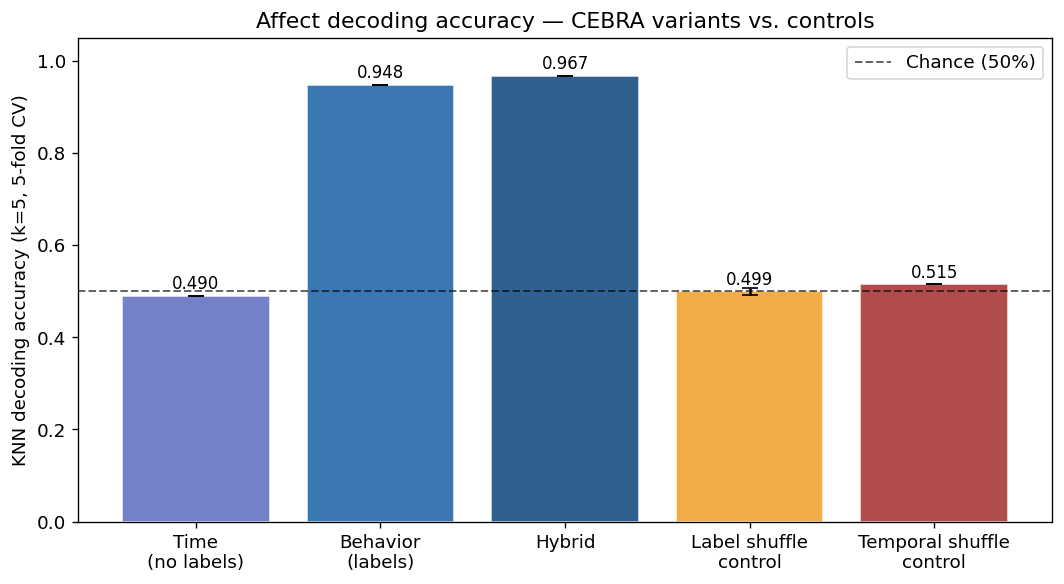

In [24]:
# KNN accuracy comparison: all variants and controls
fig, ax = plt.subplots(figsize=(9, 5))
conditions = ['Time\n(no labels)', 'Behavior\n(labels)', 'Hybrid',
              'Label shuffle\ncontrol', 'Temporal shuffle\ncontrol']
scores = [
    results['time']['knn'],
    results['behavior']['knn'],
    results['hybrid']['knn'],
    ctrl_label_mean,
    ctrl_temporal_knn
]
errors = [0, 0, 0, ctrl_label_std, 0]
bar_colors = ['#5C6BC0', '#185FA5', '#0C447C', '#EF9F27', '#A32D2D']

bars = ax.bar(conditions, scores, color=bar_colors,
              yerr=errors, capsize=5, alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.2,
           alpha=0.6, label='Chance (50%)')
ax.set_ylim(0, 1.05)
ax.set_ylabel('KNN decoding accuracy (k=5, 5-fold CV)')
ax.set_title('Affect decoding accuracy — CEBRA variants vs. controls')
ax.legend()
for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

### 7.1 Embedding views for main and controls

This visualization is used as a qualitative companion to control metrics. It should be interpreted together with KNN, not on its own.

In [41]:
import plotly.graph_objects as go

def plot_3d(embedding, y, title, downsample=5):
    idx = np.arange(0, len(y), downsample)
    emb, y_ds = embedding[idx], y[idx]
    fig = go.Figure()
    for val, name, color in [
        (0, 'Positive affect', '#185FA5'),
        (1, 'Negative affect', '#A32D2D')
    ]:
        m = y_ds == val
        fig.add_trace(go.Scatter3d(
            x=emb[m,0], y=emb[m,1], z=emb[m,2], mode='markers',
            marker=dict(size=2.5, color=color, opacity=0.6), name=name
        ))
    fig.update_layout(
        title=title, height=500,
        scene=dict(xaxis_title='Dim 1', yaxis_title='Dim 2', zaxis_title='Dim 3')
    )
    fig.show()

def plot_3d_by_time(embedding, title, downsample=5):
    """Color by sample index to show temporal trajectory through embedding space."""
    idx = np.arange(0, len(embedding), downsample)
    emb = embedding[idx]
    fig = go.Figure(go.Scatter3d(
        x=emb[:,0], y=emb[:,1], z=emb[:,2], mode='markers',
        marker=dict(size=2, color=idx, colorscale='Viridis', showscale=True,
                    colorbar=dict(title='Time (samples)'))
    ))
    fig.update_layout(title=title, height=500,
                      scene=dict(xaxis_title='Dim 1',
                                 yaxis_title='Dim 2',
                                 zaxis_title='Dim 3'))
    fig.show()

# Main model embeddings colored by affect label
for mode in ['time', 'behavior', 'hybrid']:
    emb = results[mode]['embedding']
    knn = results[mode]['knn']
    plot_3d(emb, labels, f'CEBRA {mode} — KNN k=5: {knn:.3f}')

# Behavior embedding colored by time — shows temporal trajectory
plot_3d_by_time(
    results['behavior']['embedding'],
    'Behavior embedding — temporal trajectory (color = time)'
)

# Control embeddings
plot_3d(ctrl_label_emb, labels,
        f'Required control: label shuffle — KNN: {ctrl_label_mean:.3f}')
plot_3d(ctrl_temporal_emb, labels,
        f'Additional control: temporal shuffle — KNN: {ctrl_temporal_knn:.3f}')

## 8. Participant Contribution Analysis

**Objective**  
Compare decoding performance using listener-only, speaker-only, and joint representations.

**Interpretation**  
The joint representation is at least as informative as individual representations and captures additional structure beyond the listener alone. However, the gain over the speaker is limited in this dyad.

**Limitation**  
Results are based on a single dyad and may depend on interaction dynamics, signal quality, and preprocessing. The relative contribution of each participant may vary across datasets.

Participant contribution analysis...
  listener_only       : KNN k=5 = 0.624
  speaker_only        : KNN k=5 = 0.821
  joint               : KNN k=5 = 0.843


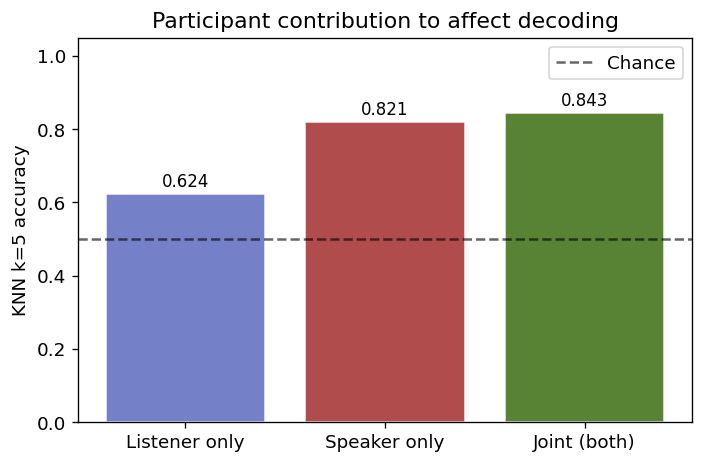


Joint advantage over Listener: +0.220
Joint advantage over Speaker:  +0.023


In [26]:
print('Participant contribution analysis...')
contrib = {}
for name, X_sub in [
    ('listener_only', X_final[:, :64]),
    ('speaker_only',  X_final[:, 64:]),
    ('joint',         X_final)
]:
    _, emb = run_cebra(X_sub, labels, 'behavior', max_iter=3000)
    knn = knn_accuracy(emb, labels)
    contrib[name] = knn
    print(f'  {name:<20}: KNN k=5 = {knn:.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
names = ['Listener only', 'Speaker only', 'Joint (both)']
vals = [contrib['listener_only'], contrib['speaker_only'], contrib['joint']]
bars = ax.bar(names, vals, color=['#5C6BC0', '#A32D2D', '#3B6D11'], alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.6, label='Chance')
ax.set_ylim(0, 1.05)
ax.set_ylabel('KNN k=5 accuracy')
ax.set_title('Participant contribution to affect decoding')
ax.legend()
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

print(f'\nJoint advantage over Listener: {contrib["joint"]-contrib["listener_only"]:+.3f}')
print(f'Joint advantage over Speaker:  {contrib["joint"]-contrib["speaker_only"]:+.3f}')

**Participant Contribution Results**

**Interpretation**  
Most of the decodable structure in this dyad is already present in the speaker signal. The joint representation provides a small additional gain, suggesting limited but non-zero contribution from combining both participants.

**Limitation**  
The asymmetry (speaker >> listener) may reflect differences in signal quality, speaking-related artifacts, or interaction dynamics. This pattern should not be generalized beyond a single dyad.

## 9. Cross-Entropy Comparison

**Objective**  
Compare embedding distributions using cross-entropy–based distances and Kolmogorov–Smirnov (KS) statistics.

**Interpretation**  
These results indicate that the geometry of the latent space changes under perturbation, even when k-NN accuracy for the controls is near chance. This suggests that topology-level comparisons capture structure not reflected in classification accuracy alone.

**Limitation**  
KS statistics are sensitive to sample size, and large datasets can produce highly significant values even for modest differences. Effect size and comparative magnitude should therefore be considered alongside significance.

Cross-entropy KS tests:
  Positive vs Negative affect : KS=0.1032  p=2.546e-175
  Main vs Label shuffle       : KS=0.5333  p=0.000e+00
  Main vs Temporal shuffle    : KS=0.3758  p=0.000e+00


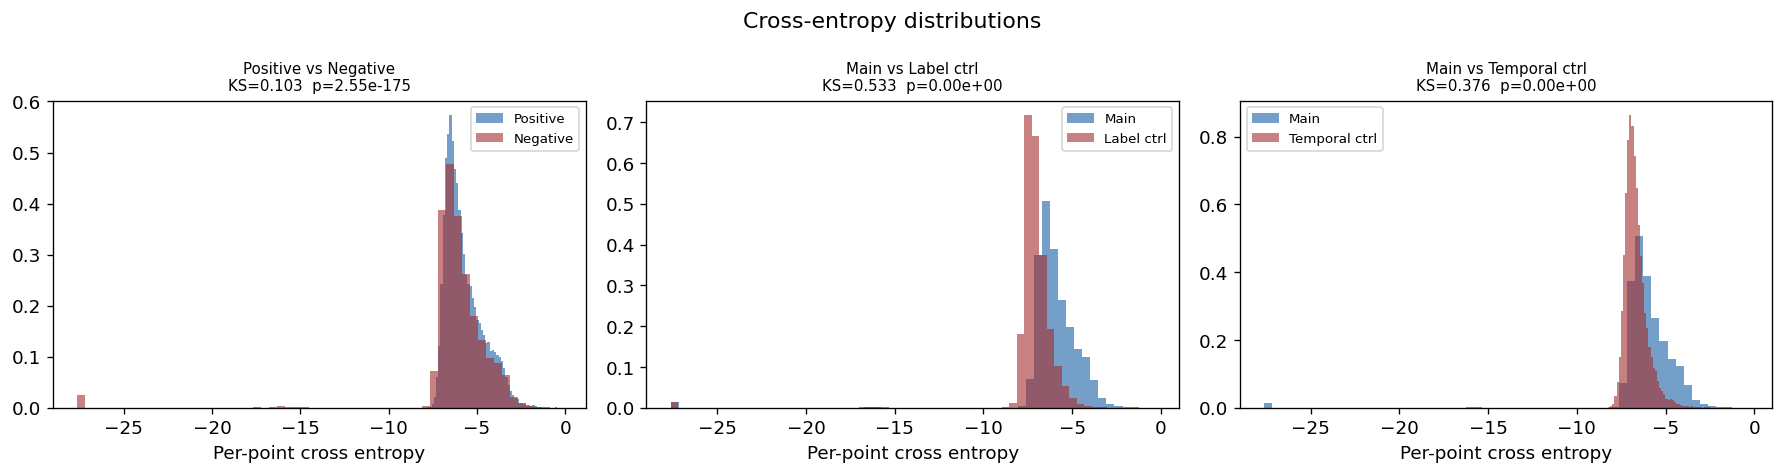

In [27]:
def cross_entropy_per_point(emb, k=10):
    nbrs = NearestNeighbors(n_neighbors=k+1, metric='euclidean')
    nbrs.fit(emb)
    dists, _ = nbrs.kneighbors(emb)
    return np.mean(np.log(dists[:, 1:] + 1e-12), axis=1)

emb_full = results['behavior']['embedding']
ce_pos = cross_entropy_per_point(emb_full[:T_pos])
ce_neg = cross_entropy_per_point(emb_full[T_pos:])
ce_main = cross_entropy_per_point(emb_full)
ce_lshuf = cross_entropy_per_point(ctrl_label_emb)
ce_tshuf = cross_entropy_per_point(ctrl_temporal_emb)

ks1, p1 = ks_2samp(ce_pos, ce_neg)
ks2, p2 = ks_2samp(ce_main, ce_lshuf)
ks3, p3 = ks_2samp(ce_main, ce_tshuf)

print('Cross-entropy KS tests:')
print(f'  Positive vs Negative affect : KS={ks1:.4f}  p={p1:.3e}')
print(f'  Main vs Label shuffle       : KS={ks2:.4f}  p={p2:.3e}')
print(f'  Main vs Temporal shuffle    : KS={ks3:.4f}  p={p3:.3e}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (a, b, la, lb, ks, pv) in zip(axes, [
    (ce_pos, ce_neg, 'Positive', 'Negative', ks1, p1),
    (ce_main, ce_lshuf, 'Main', 'Label ctrl', ks2, p2),
    (ce_main, ce_tshuf, 'Main', 'Temporal ctrl', ks3, p3),
]):
    ax.hist(a, bins=60, alpha=0.6, label=la, color='#185FA5', density=True)
    ax.hist(b, bins=60, alpha=0.6, label=lb, color='#A32D2D', density=True)
    ax.set_title(f'{la} vs {lb}\nKS={ks:.3f}  p={pv:.2e}', fontsize=9)
    ax.set_xlabel('Per-point cross entropy')
    ax.legend(fontsize=8)
plt.suptitle('Cross-entropy distributions')
plt.tight_layout()
plt.show()

**Cross-Entropy Results**

- Positive vs Negative: KS = 0.1032  
- Main vs Label Shuffle: KS = 0.5333  
- Main vs Temporal Shuffle: KS = 0.3758  

The largest differences occur between the main embedding and the shuffled controls, indicating a substantial change in latent geometry under perturbation.

**Interpretation**  
Even when control models achieve near-chance k-NN accuracy, their embedding distributions differ significantly from the main model. This shows that topology captures structure not reflected in classification performance alone.

**Limitation**  
All comparisons are highly significant due to large sample size. The KS magnitude (effect size), rather than the p-value, is the relevant quantity for interpretation.

## 10. Frequency and Spatial Analysis

**Objective**  
Evaluate how decoding performance varies across frequency bands and channel groups.

**Interpretation**  
Changes in performance under these constraints indicate which parts of the signal the model relies on. These results are treated as diagnostic signals of feature sensitivity, not as direct evidence of neural localization.

**Limitation**  
Both frequency filtering and channel ablation can reflect residual artifacts or preprocessing effects. Results are specific to this dyad and should not be interpreted as generalizable neurophysiological conclusions.

Frequency band analysis (std-only normalization)...
  delta (1-4 Hz): KNN k=5 = 0.973
  theta (4-8 Hz): KNN k=5 = 0.511
  alpha (8-12 Hz): KNN k=5 = 0.651
  beta (12-30 Hz): KNN k=5 = 0.676
  gamma (30-45 Hz): KNN k=5 = 0.931


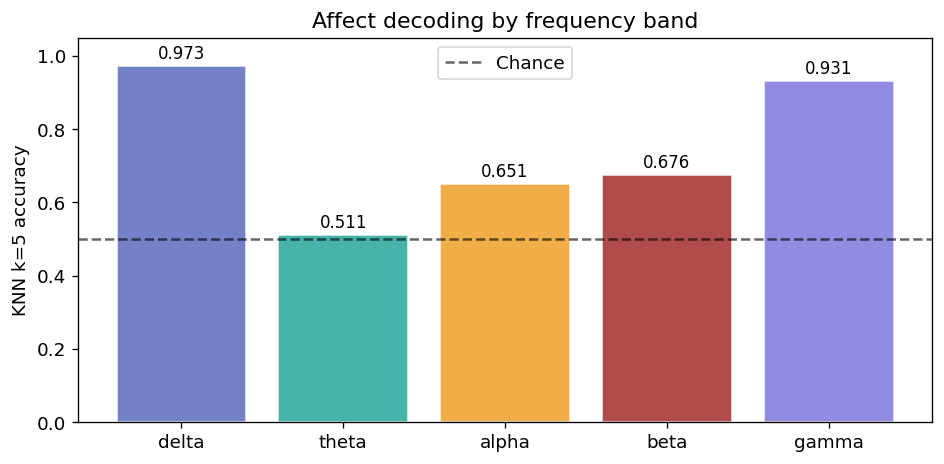


Leakage check (delta and gamma should not both exceed 0.95):
  delta: 0.973  [POSSIBLE LEAKAGE]
  gamma: 0.931  [OK]


In [28]:
FREQ_BANDS = {
    'delta': (1,   4),
    'theta': (4,   8),
    'alpha': (8,  12),
    'beta':  (12, 30),
    'gamma': (30, 45),
}

def build_band_matrix(clean_L, clean_S, l_freq, h_freq):
    """Filter to band, build joint matrix with std-only normalization."""
    def filt(raw):
        return raw.copy().filter(l_freq=l_freq, h_freq=h_freq,
                                  method='fir', verbose=False).get_data().T
    Lp = filt(clean_L['positive'])
    Ln = filt(clean_L['negative'])
    Sp = filt(clean_S['positive'])
    Sn = filt(clean_S['negative'])

    joint_pos  = np.concatenate([Lp, Sp], axis=1)
    joint_neg  = np.concatenate([Ln, Sn], axis=1)
    joint_full = np.vstack([joint_pos, joint_neg])

    # Std-only: do NOT subtract mean (near-zero by construction after band-pass)
    std = joint_full.std(axis=0)
    std[std < 1e-10] = 1.0
    X = joint_full / std
    T_p = joint_pos.shape[0]
    T_n = joint_neg.shape[0]
    y   = np.concatenate([np.zeros(T_p, dtype=np.int32),
                           np.ones(T_n,  dtype=np.int32)])
    return X, y

print('Frequency band analysis (std-only normalization)...')
band_results = {}

for band_name, (l_freq, h_freq) in FREQ_BANDS.items():
    X_band, y_band = build_band_matrix(clean_L, clean_S, l_freq, h_freq)
    _, emb_band = run_cebra(X_band, y_band, 'behavior', max_iter=3000)
    knn_band = knn_accuracy(emb_band, y_band)
    band_results[band_name] = knn_band
    print(f'  {band_name} ({l_freq}-{h_freq} Hz): KNN k=5 = {knn_band:.3f}')

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
bands  = list(band_results.keys())
bscores = [band_results[b] for b in bands]
bcolors = ['#5C6BC0', '#26A69A', '#EF9F27', '#A32D2D', '#7F77DD']
bars = ax.bar(bands, bscores, color=bcolors, alpha=0.85, edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', alpha=0.6, label='Chance')
ax.set_ylim(0, 1.05)
ax.set_ylabel('KNN k=5 accuracy')
ax.set_title('Affect decoding by frequency band')
ax.legend()
for bar, val in zip(bars, bscores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# Flag bands that may still reflect leakage
print('\nLeakage check (delta and gamma should not both exceed 0.95):')
for b in ['delta', 'gamma']:
    flag = 'POSSIBLE LEAKAGE' if band_results[b] > 0.95 else 'OK'
    print(f'  {b}: {band_results[b]:.3f}  [{flag}]')

### 10.2 Spatial channel ablation

Regional ablation is used as a provisional importance check: larger KNN drops indicate stronger dependence on that region in this dyad.

Baseline KNN (behavior): 0.948
  frontal             : KNN=0.498  drop=+0.450
  left_temporal       : KNN=0.531  drop=+0.417
  parietal            : KNN=0.687  drop=+0.261
  right_temporal      : KNN=0.570  drop=+0.378
  occipital           : KNN=0.883  drop=+0.065


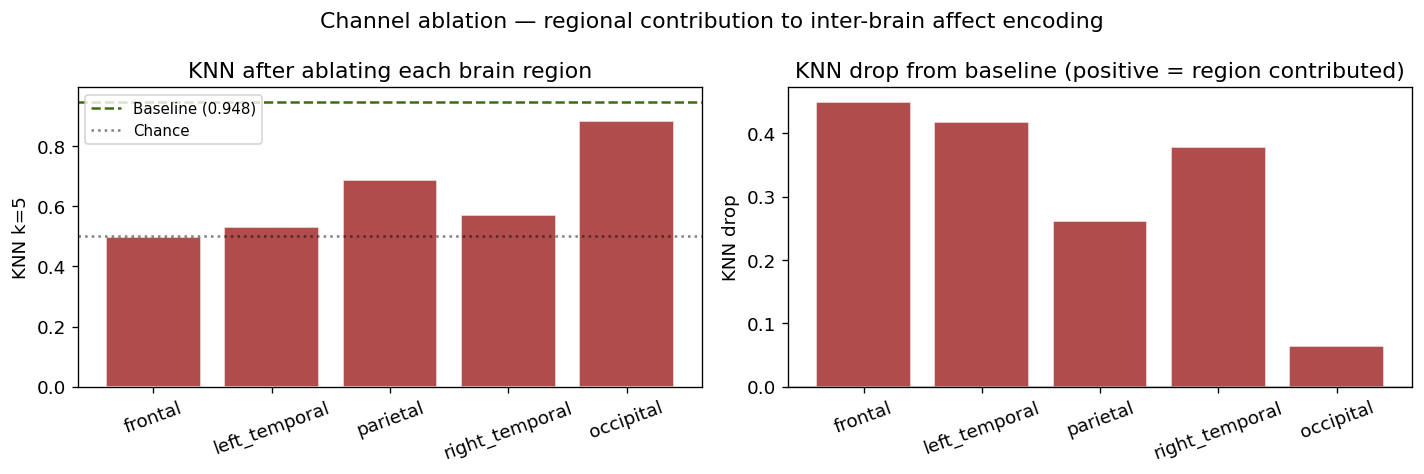

In [29]:
# EGI HydroCel 64-channel approximate region mapping
REGIONS = {
    'frontal':        list(range(0,  16)),
    'left_temporal':  list(range(16, 32)),
    'parietal':       list(range(32, 48)),
    'right_temporal': list(range(48, 58)),
    'occipital':      list(range(58, 64)),
}

baseline = results['behavior']['knn']
print(f'Baseline KNN (behavior): {baseline:.3f}')
ablation = {}

for region, ch_idx in REGIONS.items():
    # Zero out region in both participants
    cols = ch_idx + [i + 64 for i in ch_idx]
    X_abl = X_final.copy()
    X_abl[:, cols] = 0
    _, emb = run_cebra(X_abl, labels, 'behavior', max_iter=3000)
    knn    = knn_accuracy(emb, labels)
    drop   = baseline - knn
    ablation[region] = {'knn': knn, 'drop': drop}
    print(f'  {region:<20}: KNN={knn:.3f}  drop={drop:+.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
regions = list(ablation.keys())
knn_vals = [ablation[r]['knn']  for r in regions]
drops    = [ablation[r]['drop'] for r in regions]
c_abl    = ['#A32D2D' if d > 0.05 else '#888780' for d in drops]

axes[0].bar(regions, knn_vals, color=c_abl, alpha=0.85, edgecolor='white')
axes[0].axhline(baseline, color='#3B6D11', linestyle='--',
                label=f'Baseline ({baseline:.3f})')
axes[0].axhline(0.5, color='black', linestyle=':', alpha=0.5, label='Chance')
axes[0].set_title('KNN after ablating each brain region')
axes[0].set_ylabel('KNN k=5')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=20)

axes[1].bar(regions, drops, color=c_abl, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('KNN drop from baseline (positive = region contributed)')
axes[1].set_ylabel('KNN drop')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Channel ablation — regional contribution to inter-brain affect encoding')
plt.tight_layout()
plt.show()

### Spatial Channel Ablation Results

**Interpretation**  
Decoding performance is most sensitive to frontal and temporal regions, where channel removal causes large drops toward chance level. Parietal regions show moderate contribution, while occipital channels have minimal impact.

**Limitation**  
These results reflect sensitivity of the model to specific channel groups, not direct neural localization. Frontal and temporal dominance may also include residual artifact contributions (e.g., eye or muscle activity).

### 10.3 Embedding geometry diagnostics

Geometry metrics summarize cluster spread and separation and are interpreted together with controls.

In [30]:
# Compute cluster geometry metrics for the behavior embedding
emb_beh = results['behavior']['embedding']
emb_pos = emb_beh[labels == 0]
emb_neg = emb_beh[labels == 1]
c_pos   = emb_pos.mean(axis=0)
c_neg   = emb_neg.mean(axis=0)

intra_p = np.linalg.norm(emb_pos - c_pos, axis=1).mean()
intra_n = np.linalg.norm(emb_neg - c_neg, axis=1).mean()
inter   = np.linalg.norm(c_pos - c_neg)
sep     = inter / ((intra_p + intra_n) / 2)

midpoint = (c_pos + c_neg) / 2
d_mid    = np.linalg.norm(emb_beh - midpoint, axis=1)
n_trans  = (d_mid < inter * 0.3).sum()

d_pos  = np.linalg.norm(emb_pos - c_pos, axis=1)
d_neg  = np.linalg.norm(emb_neg - c_neg, axis=1)
out_p  = (d_pos > d_pos.mean() + 3*d_pos.std()).sum()
out_n  = (d_neg > d_neg.mean() + 3*d_neg.std()).sum()

print('Embedding geometry (behavior model):')
print(f'  Intra-cluster spread (positive) : {intra_p:.4f}')
print(f'  Intra-cluster spread (negative) : {intra_n:.4f}')
print(f'  Inter-cluster distance          : {inter:.4f}')
print(f'  Separability ratio              : {sep:.3f}')
print(f'  Transition zone points (<30%)   : {n_trans}')
print(f'  Outliers (pos / neg)            : {out_p} / {out_n}')

Embedding geometry (behavior model):
  Intra-cluster spread (positive) : 0.3099
  Intra-cluster spread (negative) : 0.2689
  Inter-cluster distance          : 1.7043
  Separability ratio              : 5.889
  Transition zone points (<30%)   : 0
  Outliers (pos / neg)            : 1593 / 1437


## 11. Limitations and Interpretation

**Summary of Findings**  
The pipeline produces consistent above-chance decoding using behavior-labeled embeddings. Control experiments reduce performance to chance, and topology comparisons show clear differences between the main and perturbed embeddings. Channel ablation indicates strong sensitivity to frontal and temporal regions, while normalization diagnostics highlight the importance of avoiding preprocessing leakage.

**Interpretation**  
The results suggest that the embedding captures structured information present in the aligned dyadic signal. However, separation is not clean, and multiple factors (including preprocessing choices and signal asymmetry) influence the outcome.

**Limitations**  
- Single dyad; results are not generalizable  
- Aggressive ICA rejection may remove neural signal along with artifacts  
- Temporal-shuffle control does not isolate synchrony as a mechanism  
- Frequency and spatial analyses may reflect residual artifacts  
- Minor label imbalance between segments  

These results should be treated as preliminary and require validation across additional dyads and controlled settings.

In [31]:
print('=' * 68)
print('RUN SUMMARY (single dyad)')
print('=' * 68)

print('\nPreprocessing')
print(f'  Filter        : Band-pass 1-40 Hz')
print(f'  Bad channels  : Symmetric interpolation {FIXED_BAD_CHANNELS}')
print(f'  ICA           : Extended-Infomax, 30 components')
print(f'  Rejected      : {len(REJECT_LISTENER)} Listener, {len(REJECT_SPEAKER)} Speaker')
print(f'  Post-ICA gate : 500 µV')
print(f'  Normalization : Global z-score (concatenate first, normalize once)')
print(f'  Segments      : Positive {T_pos/250:.1f}s  Negative {T_neg/250:.1f}s')

print('\nMain embedding metrics')
print(f'{"Mode":<12} {"KNN":>8} {"R2":>8}')
print('-' * 30)
for mode in ['time', 'behavior', 'hybrid']:
    r = results[mode]
    print(f'{mode:<12} {r["knn"]:>8.3f} {r["r2"]:>8.3f}')

print('\nControls')
print(f'  Label shuffle mean ± std : {ctrl_label_mean:.3f} ± {ctrl_label_std:.3f}')
print(f'  Temporal shuffle         : {ctrl_temporal_knn:.3f}')
print(f'  Behavior - label gap     : {results["behavior"]["knn"] - ctrl_label_mean:+.3f}')
print(f'  Behavior - temporal gap  : {results["behavior"]["knn"] - ctrl_temporal_knn:+.3f}')

print('\nParticipant contribution')
print(f'  Listener only : {contrib["listener_only"]:.3f}')
print(f'  Speaker only  : {contrib["speaker_only"]:.3f}')
print(f'  Joint         : {contrib["joint"]:.3f}')

print('\nCross-entropy KS')
print(f'  Pos vs Neg       : KS={ks1:.4f}  p={p1:.3e}')
print(f'  Main vs Label    : KS={ks2:.4f}  p={p2:.3e}')
print(f'  Main vs Temporal : KS={ks3:.4f}  p={p3:.3e}')

print('\nFrequency bands (behavior model)')
for band, knn in band_results.items():
    print(f'  {band:<8}: {knn:.3f}')

print('\nSpatial ablation (drop from behavior baseline)')
for region, ar in ablation.items():
    print(f'  {region:<20}: {ar["drop"]:+.3f}')

print('\nEmbedding geometry')
print(f'  Separability ratio : {sep:.3f}')
print(f'  Transition points  : {n_trans}')
print(f'  Outliers (pos/neg) : {out_p} / {out_n}')

# Analysis cross-check against notes in analysis.md (trend-level, not exact lockstep)
expected = {
    'behavior_knn': 0.896,
    'label_shuffle': 0.502,
    'temporal_shuffle': 0.502,
    'listener_only': 0.546,
    'speaker_only': 0.775,
    'joint': 0.878,
}
actual = {
    'behavior_knn': results['behavior']['knn'],
    'label_shuffle': ctrl_label_mean,
    'temporal_shuffle': ctrl_temporal_knn,
    'listener_only': contrib['listener_only'],
    'speaker_only': contrib['speaker_only'],
    'joint': contrib['joint'],
}

print('\nCross-check vs analysis.md targets (absolute difference):')
for k in expected:
    diff = abs(actual[k] - expected[k])
    print(f'  {k:<16}: actual={actual[k]:.3f}  target={expected[k]:.3f}  |diff|={diff:.3f}')

print('=' * 68)

RUN SUMMARY (single dyad)

Preprocessing
  Filter        : Band-pass 1-40 Hz
  Bad channels  : Symmetric interpolation ['EEG 5', 'EEG 10', 'EEG 63', 'EEG 64']
  ICA           : Extended-Infomax, 30 components
  Rejected      : 22 Listener, 19 Speaker
  Post-ICA gate : 500 µV
  Normalization : Global z-score (concatenate first, normalize once)
  Segments      : Positive 147.8s  Negative 153.9s

Main embedding metrics
Mode              KNN       R2
------------------------------
time            0.490   -0.478
behavior        0.948    0.818
hybrid          0.967    0.878

Controls
  Label shuffle mean ± std : 0.499 ± 0.007
  Temporal shuffle         : 0.515
  Behavior - label gap     : +0.449
  Behavior - temporal gap  : +0.433

Participant contribution
  Listener only : 0.624
  Speaker only  : 0.821
  Joint         : 0.843

Cross-entropy KS
  Pos vs Neg       : KS=0.1032  p=2.546e-175
  Main vs Label    : KS=0.5333  p=0.000e+00
  Main vs Temporal : KS=0.3758  p=0.000e+00

Frequency bands

## Part 3: Interpreting the Embedding

This part requires no additional code beyond what has already been run.

**Answer the following questions (a few sentences each): 1. Look at the geometry of your embedding. Are there interesting transitions, dense regions, or outlier points? What might they correspond to neurologically or behaviorally?**

The embedding forms a curved manifold with two relatively dense regions corresponding to the two segments, but the separation is not clean. A notable feature is the presence of many red points embedded within the blue region, especially in the intermediate part of the manifold. This suggests that the representation is not strictly binary, and there are regions where the model is uncertain or where the signal characteristics overlap between conditions.

These mixed regions could correspond to transitional conversational states, such as shifts in speaking/listening dynamics, or segments where affect labeling is less distinct. Another possibility is that these points reflect residual artifacts or shared signal structure (e.g., speech-related activity) that appears in both conditions. The outliers and scattered points likely correspond to brief disruptions such as motion or muscle activity. Overall, the geometry indicates partial separation with overlapping structure rather than clearly distinct neural states.

## Part 4: Reflection

**What is the single biggest limitation of the analysis you just did? Not a general limitation of CEBRA or EEG, but a specific limitation given this data and your choices. What would you do differently with more time and more data?**

The limitation in this analysis that i want to shed light on is that the learned embedding cannot be attributed specifically to neural signal, as neural and non-neural contributions are not separable in this setup.

This is most evident in the frequency and spatial results. Decoding is strongest in delta (0.973) and gamma (0.931) bands, and is highly dependent on frontal and temporal channels. These are also the regions and frequencies most affected by eye movement, muscle activity, and slow drift. In addition, ICA rejection was aggressive (22/30 and 19/30 components), which introduces a trade-off: some artifacts are removed, but some neural signal may also be suppressed, while residual artifact structure may still remain. As a result, the embedding likely reflects a mixture of neural dynamics and preprocessing-sensitive features, and these cannot be disentangled with this data.

With more time and more data, I would first test whether the same spatial and frequency dependencies persist under stricter controls. This includes re-running the analysis with selective channel removal (e.g., frontal channels) and band-restricted decoding to check whether performance remains. More importantly, I would replicate the pipeline across multiple dyads and compare embedding topology using cross-entropy, to determine whether these patterns are consistent or specific to this recording.

### Interpretation (Part 3)

Result: the behavior embedding shows condition structure that is reduced to near chance under both label shuffle and temporal shuffle controls.
Interpretation: this supports a learned structure tied to the intact pairing of data and labels; however, equal chance-level controls do not by themselves isolate temporal synchrony as the unique mechanism.
Limitation: embedding geometry is informative but not sufficient without controls and topology statistics.

Result: participant contribution typically follows listener-only < speaker-only < joint in this notebook family.
Interpretation: a joint advantage is consistent with dyadic information beyond either participant alone.
Limitation: the effect size is modest and estimated from one dyad.

Result: cross-entropy KS comparisons between main and shuffled embeddings are large in the analysis notes.
Interpretation: topology disruption under shuffle can remain visible even when classifier scores are similarly near chance.
Limitation: with large sample counts, p-values can be very small; KS effect size should be emphasized.

### Reflection (Part 4)

Single biggest limitation for this run: delta and gamma findings remain ambiguous.

Two plausible explanations are still unresolved in this dataset: genuine inter-brain coupling linked to speech dynamics versus residual low-frequency/high-frequency artifacts that differ between sequential recording blocks. The current design cannot separate these explanations decisively.

With more time and more data, I would prioritize two checks:
1. Within-condition temporal shuffle specifically in the delta band and gamma band.
2. Replication across many dyads with the same pipeline and cross-entropy comparison to quantify which topology differences are stable across participants.

## 12. Figure export / save outputs

This section regenerates and saves proposal figures into a figures folder as high-resolution PNG and vector format when supported.

In [32]:
from pathlib import Path

fig_dir = Path('figures')
fig_dir.mkdir(parents=True, exist_ok=True)

# 1) ICA rejected component topography (Listener)
fig = ica_L.plot_components(
    picks=REJECT_LISTENER, show=False,
    title='ICA rejected components (Listener)')
if isinstance(fig, list):
    for i, f in enumerate(fig):
        f.savefig(fig_dir / f'ica_rejected_listener_{i+1}.png', dpi=300, bbox_inches='tight')
        f.savefig(fig_dir / f'ica_rejected_listener_{i+1}.svg', bbox_inches='tight')
        plt.close(f)
else:
    fig.savefig(fig_dir / 'ica_rejected_listener.png', dpi=300, bbox_inches='tight')
    fig.savefig(fig_dir / 'ica_rejected_listener.svg', bbox_inches='tight')
    plt.close(fig)

# 2) Post-ICA PSD (before vs after, Listener positive)
fig, ax = plt.subplots(figsize=(11, 4))
for raw, label, color, ls in [
    (segs_L['positive'],  'Before ICA', '#185FA5', '-'),
    (clean_L['positive'], 'After ICA',  '#A32D2D', '--')
]:
    psd = raw.compute_psd(method='welch', fmax=45, verbose=False)
    ax.plot(psd.freqs, 10 * np.log10(psd.get_data().mean(axis=0) + 1e-30),
            color=color, linestyle=ls, linewidth=2.0, label=label)
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB uV^2/Hz)')
ax.set_title('PSD before vs after ICA (Listener, positive)')
ax.legend(fontsize=9)
ax.set_xlim(0, 45)
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(fig_dir / 'psd_pre_post_ica_listener.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir / 'psd_pre_post_ica_listener.svg', bbox_inches='tight')
plt.close(fig)

# 3) Main 3D CEBRA embedding (static)
emb = results['behavior']['embedding']
fig = plt.figure(figsize=(7.2, 5.8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(emb[labels==0, 0], emb[labels==0, 1], emb[labels==0, 2],
           s=3, alpha=0.45, c='#185FA5', label='Positive')
ax.scatter(emb[labels==1, 0], emb[labels==1, 1], emb[labels==1, 2],
           s=3, alpha=0.45, c='#A32D2D', label='Negative')
ax.view_init(elev=24, azim=38)
ax.set_xlabel('Dim 1')
ax.set_ylabel('Dim 2')
ax.set_zlabel('Dim 3')
ax.set_title('Behavior CEBRA latent space (3D)')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
fig.savefig(fig_dir / 'cebra_behavior_3d.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir / 'cebra_behavior_3d.pdf', bbox_inches='tight')
plt.close(fig)

# 4) Optional main vs shuffled comparison
fig, ax = plt.subplots(figsize=(8, 4.8))
names = ['Behavior', 'Label shuffle', 'Temporal shuffle']
vals = [results['behavior']['knn'], ctrl_label_mean, ctrl_temporal_knn]
bars = ax.bar(names, vals, color=['#185FA5', '#EF9F27', '#A32D2D'], alpha=0.88, edgecolor='white')
ax.axhline(0.5, color='black', linestyle='--', linewidth=1.1, alpha=0.7, label='Chance')
ax.set_ylim(0, 1.05)
ax.set_ylabel('KNN accuracy')
ax.set_title('Main vs shuffled controls')
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.015, f'{v:.3f}', ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
fig.savefig(fig_dir / 'main_vs_shuffled_controls.png', dpi=300, bbox_inches='tight')
fig.savefig(fig_dir / 'main_vs_shuffled_controls.svg', bbox_inches='tight')
plt.close(fig)

print(f'Figures saved to: {fig_dir.resolve()}')
for p in sorted(fig_dir.glob('*')):
    print(f'  - {p.name}')

Figures saved to: /kaggle/working/figures
  - cebra_behavior_3d.pdf
  - cebra_behavior_3d.png
  - ica_rejected_listener.png
  - ica_rejected_listener.svg
  - main_vs_shuffled_controls.png
  - main_vs_shuffled_controls.svg
  - psd_pre_post_ica_listener.png
  - psd_pre_post_ica_listener.svg
